<a href="https://colab.research.google.com/github/fargonemaciel/infnet-machine-learning-codes/blob/main/feature_engineering_fargone_maciel_flor_DR2_AT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dados para Machine Learning: Feature Engineering [26E1_2]

### Assessment [Obrigatório]

In [1]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]

In [81]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 42.2 MB/s eta 0:00:00


In [60]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [125]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk

from kagglehub import KaggleDatasetAdapter
from warnings import filterwarnings
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, FeatureHasher
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mglearn.tools import visualize_coefficients
from sklearn.decomposition import PCA


filterwarnings('ignore')

In [3]:
path = kagglehub.dataset_download('olistbr/brazilian-ecommerce')
print(f"O caminho do dataset é: {path}")

files = {
    'customers' : 'olist_customers_dataset.csv',
    'geolocation' : 'olist_geolocation_dataset.csv',
    'items' : 'olist_order_items_dataset.csv',
    'payment' : 'olist_order_payments_dataset.csv',
    'orders' : 'olist_orders_dataset.csv',
    'products' : 'olist_products_dataset.csv',
    'sellers' : 'olist_sellers_dataset.csv',
    'review' : 'olist_order_reviews_dataset.csv',
}

dfs = {}
for file, filename in files.items():
    dfs[file] = pd.read_csv(path + '/' + filename)

customers_location = dfs['customers'].merge(dfs['geolocation'], how='inner', left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix').drop_duplicates('customer_id', keep='first')
cusloc_order = customers_location.merge(dfs['orders'], how='inner', on='customer_id')
cuslocord_item = cusloc_order.merge(dfs['items'], how='inner', on='order_id')
cuslocordite_prod = cuslocord_item.merge(dfs['products'], how='inner', on='product_id')
cuslocordite_rev = cuslocordite_prod.merge(dfs['review'], how='left', on='order_id')

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
O caminho do dataset é: /kaggle/input/brazilian-ecommerce


In [4]:
cuslocordite_rev.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,14409,-20.509897,-47.397866,franca,SP,...,8683.0,54.0,64.0,31.0,88b8b52d46df026a9d1ad2136a59b30b,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,9790,-23.726853,-46.545746,sao bernardo do campo,SP,...,10150.0,89.0,15.0,40.0,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,1151,-23.527788,-46.660310,sao paulo,SP,...,8267.0,52.0,52.0,17.0,5ad6695d76ee186dc473c42706984d87,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,8775,-23.496930,-46.185352,mogi das cruzes,SP,...,12160.0,56.0,51.0,28.0,059a801bb31f6aab2266e672cab87bc5,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,13056,-22.987222,-47.151073,campinas,SP,...,5200.0,45.0,15.0,35.0,8490879d58d6c5d7773f2739a03f089a,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52


In [5]:
cuslocordite_rev.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'geolocation_zip_code_prefix',
       'geolocation_lat', 'geolocation_lng', 'geolocation_city',
       'geolocation_state', 'order_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'order_item_id', 'product_id',
       'seller_id', 'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [6]:
dados = cuslocordite_rev[[
    'customer_unique_id',
    'customer_zip_code_prefix', 'customer_city', 'customer_state',
    'order_status', 'order_purchase_timestamp', 'order_approved_at',
    'shipping_limit_date', 'order_delivered_carrier_date',
    'order_estimated_delivery_date', 'order_delivered_customer_date',
    'order_item_id', 'product_id', 'seller_id',
    'price', 'freight_value',
    'product_category_name', 'product_photos_qty',
    'review_score',
    'review_comment_title', 'review_comment_message',
    'review_creation_date', 'review_answer_timestamp'
]]

In [7]:
df = dados
df.head()

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,...,seller_id,price,freight_value,product_category_name,product_photos_qty,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-22 15:22:12,2017-05-23 10:47:57,2017-06-05 00:00:00,...,7c67e1448b00f6e969d365cea6b010ab,124.99,21.88,moveis_escritorio,1.0,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-18 20:58:32,2018-01-15 17:14:59,2018-02-06 00:00:00,...,b8bc237ba3788b23da09c0f1f3a3288c,289.00,46.48,utilidades_domesticas,3.0,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-05 16:19:10,2018-06-11 14:31:00,2018-06-13 00:00:00,...,7c67e1448b00f6e969d365cea6b010ab,139.94,17.79,moveis_escritorio,1.0,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59
3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 16:31:16,2018-03-27 23:22:42,2018-04-10 00:00:00,...,7c67e1448b00f6e969d365cea6b010ab,149.94,23.36,moveis_escritorio,1.0,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47
4,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-31 10:10:09,2018-07-30 15:16:00,2018-08-15 00:00:00,...,4a3ca9315b744ce9f8e9374361493884,230.00,22.25,casa_conforto,1.0,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52


### PARTE I Conceitos

Questão 1: Examine os dados e, para cada atributo abaixo, diga se o dado seria de natureza numérica, textual, ou categórica.

customer_id --> coluna não selecionada;

geolocation_lat --> coluna não selecionada;

customer_city --> categórica;

review_comment_title --> textual;

freight_value --> numérica.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113007 entries, 0 to 113006
Data columns (total 23 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_unique_id             113007 non-null  object 
 1   customer_zip_code_prefix       113007 non-null  int64  
 2   customer_city                  113007 non-null  object 
 3   customer_state                 113007 non-null  object 
 4   order_status                   113007 non-null  object 
 5   order_purchase_timestamp       113007 non-null  object 
 6   order_approved_at              112992 non-null  object 
 7   shipping_limit_date            113007 non-null  object 
 8   order_delivered_carrier_date   111811 non-null  object 
 9   order_estimated_delivery_date  113007 non-null  object 
 10  order_delivered_customer_date  110546 non-null  object 
 11  order_item_id                  113007 non-null  int64  
 12  product_id                    

In [9]:
df['customer_unique_id'].value_counts()

,count
customer_unique_id,
d97b3cfb22b0d6b25ac9ed4e9c2d481b,24
c8460e4251689ba205045f3ea17884a1,24
4546caea018ad8c692964e3382debd19,21
698e1cf81d01a3d389d96145f7fa6df8,20
c402f431464c72e27330a67f7b94d4fb,20
...,...
eaaec87b3486abc4078e664e7b8ae8ad,1
db8e17d05979207386d9afaa929a52a1,1
b636fa8d093c315e98bc4911a301a42b,1


In [10]:
df['customer_city'].value_counts()

,count
customer_city,
sao paulo,17930
rio de janeiro,7887
belo horizonte,3171
brasilia,2229
curitiba,1758
...,...
santo antonio do leste,1
marcos parente,1
natividade da serra,1


In [11]:
df['review_comment_title'].value_counts().head()

,count
review_comment_title,
Recomendo,469
recomendo,392
Bom,321
super recomendo,306
Excelente,279


In [12]:
df['freight_value'].value_counts().head()

,count
freight_value,
15.10,3721
7.78,2278
14.10,1877
11.85,1871
18.23,1575


In [13]:
df.describe(include='all')

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,...,seller_id,price,freight_value,product_category_name,product_photos_qty,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,113007,113007.000000,113007,113007,113007,113007,112992,113007,111811,113007,...,113007,113007.000000,113007.000000,111401,111401.000000,112066.000000,13389,47514,112066,112066
unique,95156,NaN,4066,27,7,97842,89942,93080,80825,450,...,3095,NaN,NaN,73,NaN,NaN,4483,35599,633,97275
top,d97b3cfb22b0d6b25ac9ed4e9c2d481b,NaN,sao paulo,SP,delivered,2017-10-17 13:06:29,2018-02-24 03:20:27,2017-10-24 13:06:21,2018-05-09 15:48:00,2017-12-20 00:00:00,...,6560211a19b47992c3666cc44a7e94c0,NaN,NaN,cama_mesa_banho,NaN,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-07-30 14:19:07
freq,24,NaN,17930,47704,110547,22,23,22,48,609,...,2033,NaN,NaN,11242,NaN,NaN,469,254,516,21
mean,NaN,35044.656694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,120.465649,19.972842,NaN,2.206856,4.032508,NaN,NaN,NaN,NaN
std,NaN,29857.118347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,183.322932,15.786616,NaN,1.719518,1.387789,NaN,NaN,NaN,NaN
min,NaN,1003.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.850000,0.000000,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,11095.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,39.900000,13.070000,NaN,1.000000,4.000000,NaN,NaN,NaN,NaN
50%,NaN,24240.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,74.900000,16.250000,NaN,1.000000,5.000000,NaN,NaN,NaN,NaN
75%,NaN,58432.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,134.900000,21.150000,NaN,3.000000,5.000000,NaN,NaN,NaN,NaN


In [14]:
df.isna().sum().sort_values(ascending=False)

,0
review_comment_title,99618
review_comment_message,65493
order_delivered_customer_date,2461
product_category_name,1606
product_photos_qty,1606
order_delivered_carrier_date,1196
review_score,941
review_answer_timestamp,941
review_creation_date,941
order_approved_at,15


### PARTE II Prática com dados numéricos

Questão 2: Suponha que você pretende avaliar o grau de insatisfação dos clientes com atrasos na entrega. Para isso, você quer um atributo com o número de dias transcorridos desde o momento da compra e a entrega efetiva ao cliente (fracionário, duas casas decimais). Crie o atributo a partir dos dados disponíveis.

In [15]:
colunas_data = [
    'order_purchase_timestamp',
    'order_delivered_customer_date'
]

for col in colunas_data:
  df[col] = pd.to_datetime(df[col])

In [16]:
df['dias_entrega'] = (
    df['order_delivered_customer_date'] - df['order_purchase_timestamp']
).dt.total_seconds() / (24 * 3600)

In [17]:
df['dias_entrega'] = df['dias_entrega'].round(1)

In [18]:
df['dias_entrega']

,dias_entrega
0,8.8
1,16.7
2,26.1
3,15.0
4,11.5
...,...
113002,6.2
113003,7.4
113004,31.0
113005,13.0


In [19]:
df['dias_entrega'].isna().sum()

np.int64(2461)

In [20]:
df['dias_entrega'].describe()

,dias_entrega
count,110546.000000
mean,12.469000
std,9.436358
min,0.500000
25%,6.700000
50%,10.200000
75%,15.500000
max,209.600000


Questão 3: Considere as seguintes features numéricas do dataset, inclusive a que você acabou de criar: 'price', 'freight_value', 'review_score', 'product_photos_qty', 'dias_entrega'. Trace o histograma dessas 5 variáveis numéricas para entender sua distribuição.

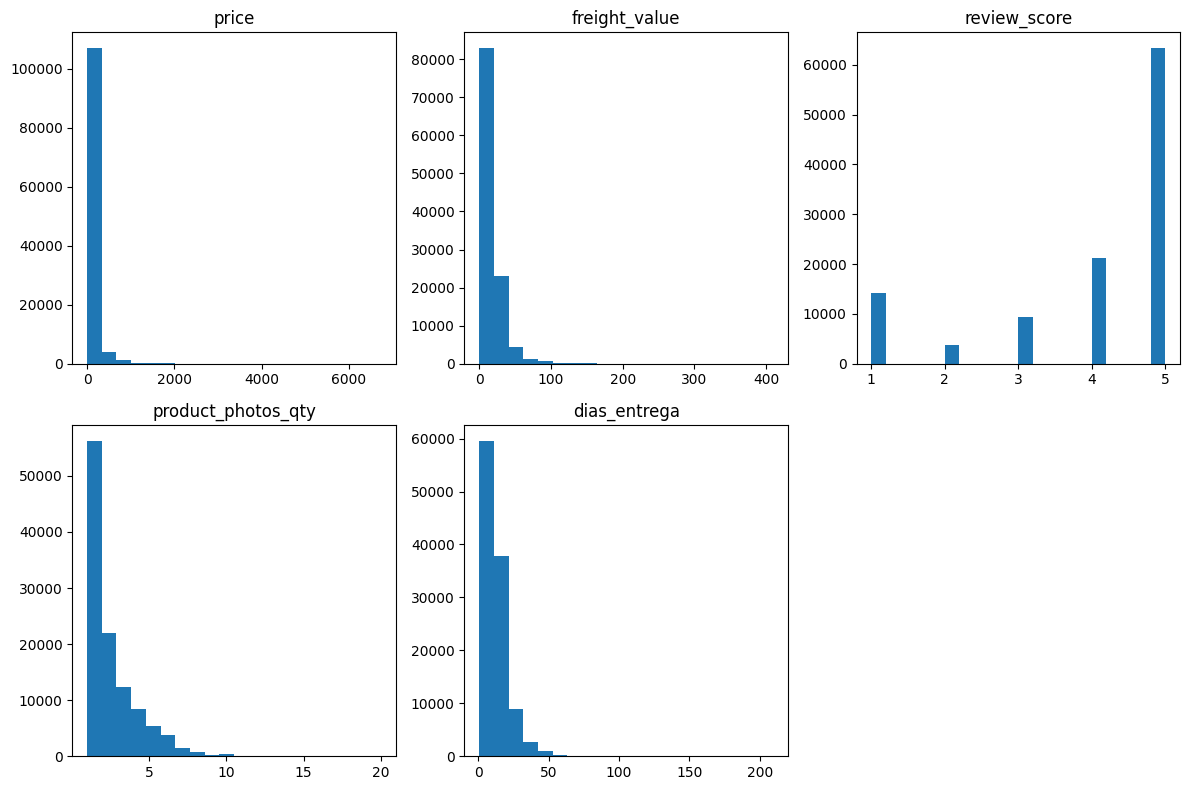

In [21]:
colunas = ['price', 'freight_value', 'review_score', 'product_photos_qty', 'dias_entrega']

plt.figure(figsize=(12, 8))

for i, col in enumerate(colunas):
  plt.subplot(2, 3, i + 1)
  plt.hist(df[col].dropna(), bins=20)
  plt.title(col)

plt.tight_layout()
plt.show()

Questão 4: Você nota que os histogramas de preço, frete e dias de entrega apresentam uma distribuição com a grande maioria das ocorrências à esquerda e uma cauda longa à direita. Identifique qual a transformação mais promissora para esses casos, aplique-a, retrace os histogramas e explique o que melhorou.

In [22]:
cols_assimetricas = ['price', 'freight_value', 'dias_entrega']

for col in cols_assimetricas:
  df[col + '_log'] = np.log1p(df[col])

df.head()

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,...,product_photos_qty,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,dias_entrega,price_log,freight_value_log,dias_entrega_log
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-22 15:22:12,2017-05-23 10:47:57,2017-06-05 00:00:00,...,1.0,4.0,NaN,NaN,2017-05-26 00:00:00,2017-05-30 22:34:40,8.8,4.836203,3.130263,2.282382
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-18 20:58:32,2018-01-15 17:14:59,2018-02-06 00:00:00,...,3.0,5.0,NaN,NaN,2018-01-30 00:00:00,2018-02-10 22:43:29,16.7,5.669881,3.860309,2.873565
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-05 16:19:10,2018-06-11 14:31:00,2018-06-13 00:00:00,...,1.0,5.0,NaN,NaN,2018-06-15 00:00:00,2018-06-15 12:10:59,26.1,4.948334,2.933325,3.299534
3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 16:31:16,2018-03-27 23:22:42,2018-04-10 00:00:00,...,1.0,5.0,NaN,NaN,2018-03-29 00:00:00,2018-04-02 18:36:47,15.0,5.016882,3.192942,2.772589
4,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-31 10:10:09,2018-07-30 15:16:00,2018-08-15 00:00:00,...,1.0,5.0,a melhor nota,O baratheon è esxelente Amo adoro o baratheon,2018-08-10 00:00:00,2018-08-17 01:59:52,11.5,5.442418,3.146305,2.525729


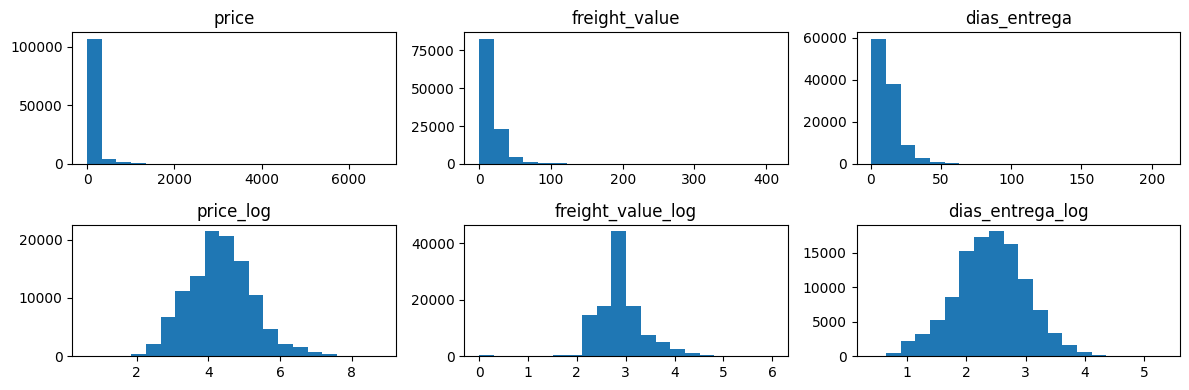

In [23]:
cols = ['price', 'freight_value', 'dias_entrega', 'price_log', 'freight_value_log', 'dias_entrega_log']

plt.figure(figsize=(12, 4))

for i, col in enumerate(cols):
  plt.subplot(2, 3, i + 1)
  plt.hist(df[col], bins=20)
  plt.title(col)

plt.tight_layout()
plt.show()

**Análise**: EM minha visão, quando dados estão muito à esquerda com cauda longa, a transformação logarítimica ajuda e muito a análise de padrões ao deixar a distribuição mais simétrica reduzindo a cauda longa. Na prática, valores extremos (outliers talvez) foram suavizados e agora conseguimos ver melhor a concentração dos dados.

Questão 5: Você observa, pelo histograma de review_score (nota de avaliação do cliente, de 1 a 5), que o atributo tem forte viés para 4 e 5, e que isso pode induzir os modelos a uma interpretação artificialmente otimista. Ao mesmo tempo, especialistas em e-commerce te informam que as empresas estão mais preocupadas em saber se o cliente está ou não satisfeito, interpretando as notas 4 e 5 como satisfeito, e as restantes, como insatisfeito. Binarize (0 ou 1), portanto, o review_score, conforme essa interpretação.

In [24]:
df['review_score'].value_counts()

,count
review_score,
5.0,63352
4.0,21256
1.0,14194
3.0,9401
2.0,3863


In [25]:
map_score = {
    1: 0,
    2: 0,
    3: 0,
    4: 1,
    5: 1
}

df['review_score_bin'] = df['review_score'].map(map_score)

In [26]:
df['review_score_bin'].value_counts()

,count
review_score_bin,
1.0,84608
0.0,27458


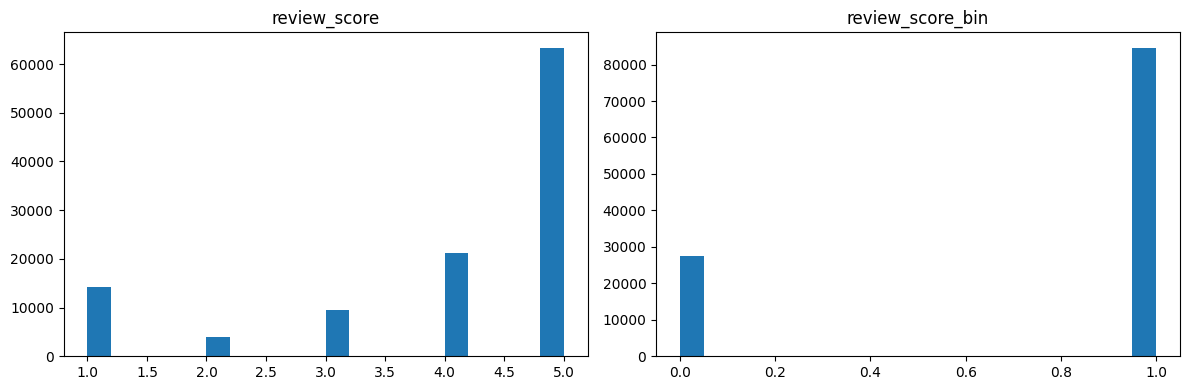

In [27]:
cols_reviews = ['review_score', 'review_score_bin']

plt.figure(figsize=(12, 4))

for i, col in enumerate(cols_reviews):
  plt.subplot(1, 2, i + 1)
  plt.hist(df[col], bins=20)
  plt.title(col)

plt.tight_layout()
plt.show()

Questão 6: Você nota que o atributo product_photos_qty (quantidade de fotos no anúncio do produto), também pode se beneficiar de quantização, pois sua distribuição é bastante desigual e esparsa. Especialistas em e-commerce te informam que, na prática, consideram uma foto, o mínimo necessário para um anúncio; 2 ou 3, uma quantidade razoável; 4 a 6, boa; e de 7 em diante, ótima. Quantize o atributo de acordo com a regra de negócio e retrace o histograma com os 4 bins resultantes.

In [28]:
df['product_photos_qty'].sort_values()

,product_photos_qty
113003,1.0
112999,1.0
112996,1.0
112995,1.0
112994,1.0
...,...
112540,NaN
112673,NaN
112674,NaN
112766,NaN


In [29]:
df['product_photos_qty'].unique()

array([ 1.,  3.,  2., nan,  5.,  8.,  6.,  4., 10.,  7.,  9., 11., 12.,
       19., 13., 15., 14., 18., 17., 20.])

In [30]:
df['product_photos_qty'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 113007 entries, 0 to 113006
Series name: product_photos_qty
Non-Null Count   Dtype  
--------------   -----  
111401 non-null  float64
dtypes: float64(1)
memory usage: 883.0 KB


In [31]:
def categorizar_product_photos(x):
  if x == 1:
    return 'Mínimo'
  elif x in [2, 3]:
    return 'Razoável'
  elif 4 <= x <= 6:
    return 'Bom'
  elif x >= 7:
    return 'Ótimo'
  else:
    return 'Insuficiente'

df['categorizacao_qnt_photos'] = df['product_photos_qty'].apply(categorizar_product_photos)

In [32]:
df['categorizacao_qnt_photos'].value_counts()

,count
categorizacao_qnt_photos,
Mínimo,56288
Razoável,34443
Bom,17602
Ótimo,3068
Insuficiente,1606


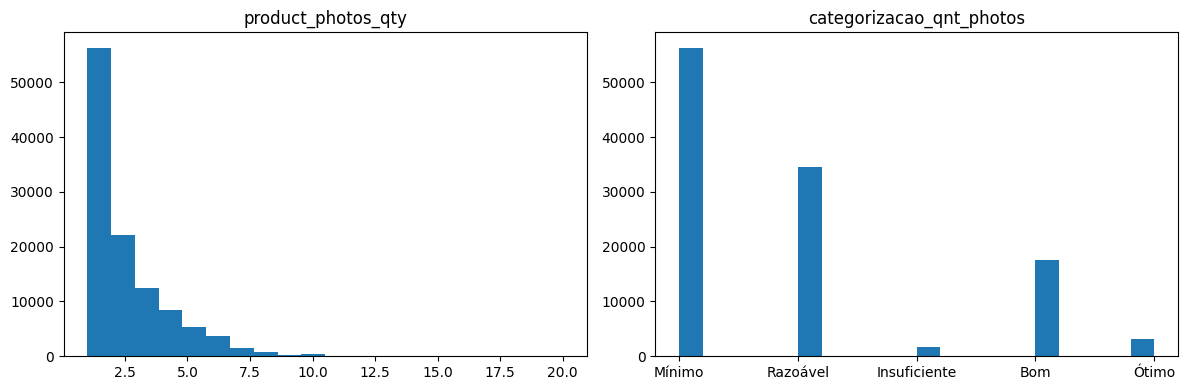

In [33]:
cols_photos = ['product_photos_qty', 'categorizacao_qnt_photos']

plt.figure(figsize=(12, 4))

for i, col in enumerate(cols_photos):
  plt.subplot(1, 2, i + 1)
  plt.hist(df[col], bins=20)
  plt.title(col)

plt.tight_layout()
plt.show()

Questão 7: Escalone os atributos numéricos contínuos transformados na Questão 4. Escolha uma função de escalonamento, justifique e aplique a transformação. Compare os boxplots dos 3 atributos antes e depois da normalização.

In [34]:
df_clean = df.copy()

In [35]:
cols_log = ['price_log', 'freight_value_log', 'dias_entrega_log']

df_clean = df_clean.dropna(subset=colunas)

In [36]:
print(df.shape)
print(df_clean.shape)

(113007, 29)
(108192, 29)


In [37]:
scaler = StandardScaler()

cols_log_scaled = [col + '_scaled' for col in cols_log]

df_clean[cols_log_scaled] = scaler.fit_transform(df_clean[cols_log])

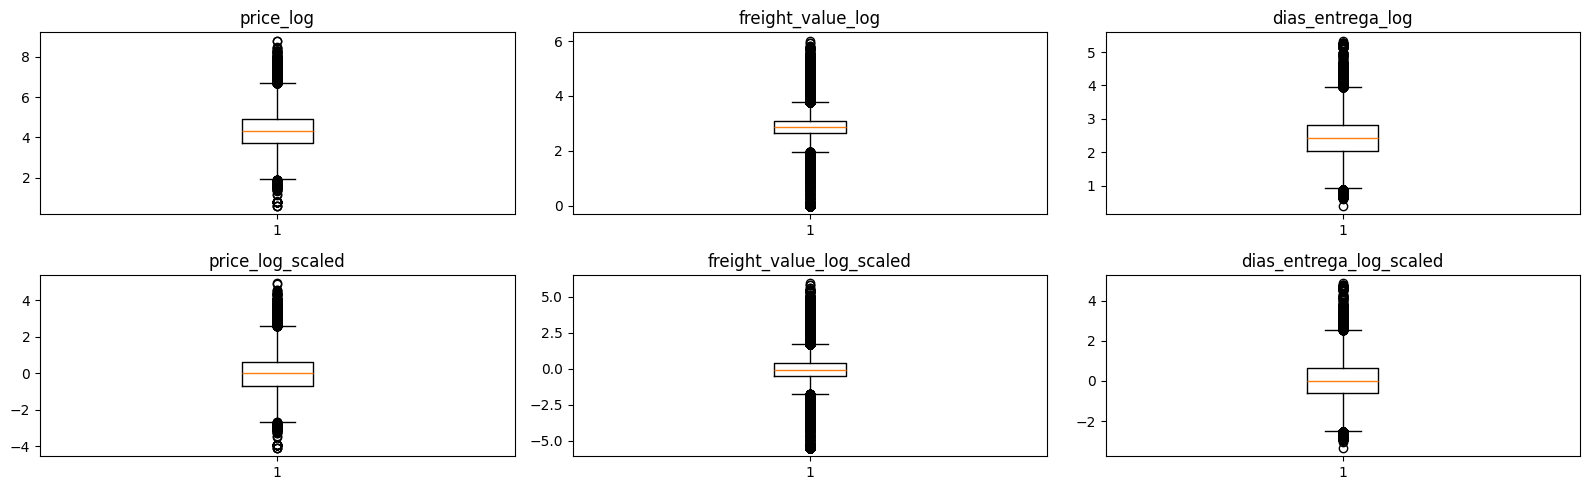

In [38]:
cols = cols_log + cols_log_scaled

plt.figure(figsize=(16, 5))

for i, col in enumerate(cols):
  plt.subplot(2, 3, i + 1)
  plt.boxplot(df_clean[col])
  plt.title(col)

plt.tight_layout()
plt.show()

**Análise**: O escalonamento das três variáveis agora facilita a comparação das três variáveis em um modelo, principalmente os baseados em distãncias, pois as escalas agora são comparáveis entre si. É isso que o escalonamento objetiva fazer.

### PARTE III Prática com dados textuais

Questão 8: A coluna 'review_comment_message' contém as avaliações de produtos feitas pelos clientes. Realize uma limpeza básica do atributo e vetorize-o com n-gramas de primeira e segunda ordem (ngram_range=(1,2)), removendo stopwords com lista adequada ao idioma. Imprima o número de tokens obtido, bem como uma amostra com cerca de 100 n-gramas do seu vetor de n-gramas resultante.
Dica: utilize strip_accents na vetorização para remover acentos, evitando, por exemplo, que “otimo” e “ótimo” assumam tokens diferentes.

In [42]:
df['review_comment_message'].tail()

,review_comment_message
113002,NaN
113003,NaN
113004,Esperava qualidade no atendimento e estou tend...
113005,NaN
113006,"Produto chegou bem antes do prazo , gostei mui..."


In [43]:
df_texto = df.copy()

df_texto = df_texto.dropna(subset=['review_comment_message'])

df_texto['review_comment_message'] = (
    df_texto['review_comment_message']
    .astype(str)
    .str.lower()
    .str.strip()
)

In [45]:
df_texto['review_comment_message'].tail()

,review_comment_message
112992,gostei do produto
112997,ótimo
113001,tenho reclamaçoes quanto ao produto. nao atend...
113004,esperava qualidade no atendimento e estou tend...
113006,"produto chegou bem antes do prazo , gostei mui..."


In [58]:
stopwords_pt_br = stopwords.words('portuguese')

vetorizador = CountVectorizer(
    stop_words=stopwords_pt_br,
    strip_accents='unicode',
    ngram_range=(1, 2)
)

X_texto = vetorizador.fit_transform(df_texto['review_comment_message'])

tokens = vetorizador.get_feature_names_out()

print(f"Número de tokens: {len(tokens)}")
print(f"100 primeiros n-gramas:\n{tokens[:100]}")

Número de tokens: 122802
100 primeiros n-gramas:
['00' '00 00' '00 20' '00 210' '00 35' '00 50' '00 55' '00 60' '00 80'
 '00 achei' '00 ainda' '00 bacana' '00 barato' '00 cada' '00 diferenca'
 '00 entanto' '00 entao' '00 entregaram' '00 fico' '00 frente' '00 frete'
 '00 gostaria' '00 hs' '00 inferior' '00 mandaram' '00 manha' '00 maximo'
 '00 mesma' '00 metro' '00 miopia' '00 mm' '00 nao' '00 opiniao'
 '00 outro' '00 paguei' '00 positivo' '00 preciso' '00 promocao'
 '00 quase' '00 reais' '00 recebi' '00 retirar' '00 sendo' '00 tiracao'
 '00 vale' '00 veio' '00 vista' '000' '000 btu' '000 btus' '000 ml'
 '000580' '000580 ajudante' '001063' '001063 iten' '001689'
 '001689 aguardo' '003566' '003566 ja' '003570' '003570 controle' '00m'
 '00m 70m' '00x' '00x 20' '00x2' '00x2 50' '00x2 50mts' '00x2 80' '01'
 '01 01' '01 02' '01 03' '01 05' '01 06' '01 07' '01 08' '01 09' '01 10'
 '01 11' '01 12' '01 18' '01 20' '01 2017' '01 2018' '01 40' '01 acredito'
 '01 ainda' '01 anel' '01 aonde' '01 ap

Questão 9: Realize a vetorização e redimensionamento da mesma feature 'review_comment_message' utilizando a técnica TF-IDF. Compare e comente os resultados.

In [61]:
vetorizador_tfidf = TfidfVectorizer(
    stop_words=stopwords_pt_br,
    strip_accents='unicode',
    ngram_range=(1, 2)
)

X_texto_tfidf = vetorizador_tfidf.fit_transform(df_texto['review_comment_message'])

tokens_tfidf = vetorizador_tfidf.get_feature_names_out()

print(f"Número de tokens: {len(tokens_tfidf)}")
print(f"100 primeiros n-gramas com TF-IDF:\n{tokens_tfidf[:100]}")

Número de tokens: 122802
100 primeiros n-gramas com TF-IDF:
['00' '00 00' '00 20' '00 210' '00 35' '00 50' '00 55' '00 60' '00 80'
 '00 achei' '00 ainda' '00 bacana' '00 barato' '00 cada' '00 diferenca'
 '00 entanto' '00 entao' '00 entregaram' '00 fico' '00 frente' '00 frete'
 '00 gostaria' '00 hs' '00 inferior' '00 mandaram' '00 manha' '00 maximo'
 '00 mesma' '00 metro' '00 miopia' '00 mm' '00 nao' '00 opiniao'
 '00 outro' '00 paguei' '00 positivo' '00 preciso' '00 promocao'
 '00 quase' '00 reais' '00 recebi' '00 retirar' '00 sendo' '00 tiracao'
 '00 vale' '00 veio' '00 vista' '000' '000 btu' '000 btus' '000 ml'
 '000580' '000580 ajudante' '001063' '001063 iten' '001689'
 '001689 aguardo' '003566' '003566 ja' '003570' '003570 controle' '00m'
 '00m 70m' '00x' '00x 20' '00x2' '00x2 50' '00x2 50mts' '00x2 80' '01'
 '01 01' '01 02' '01 03' '01 05' '01 06' '01 07' '01 08' '01 09' '01 10'
 '01 11' '01 12' '01 18' '01 20' '01 2017' '01 2018' '01 40' '01 acredito'
 '01 ainda' '01 anel' '01 ao

In [65]:
freq_count_vectorizer = pd.Series(X_texto.toarray().sum(axis=0), index=vetorizador.get_feature_names_out())

top10_count_vectorizer = freq_count_vectorizer.sort_values(ascending=False).head(10)

print(top10_count_vectorizer)

produto      20174
nao          14103
prazo         9232
entrega       7298
recebi        7178
chegou        6320
antes         6090
bom           5145
recomendo     4761
entregue      4589
dtype: int64


In [66]:
freq_tfidf = pd.Series(X_texto_tfidf.toarray().sum(axis=0), index=vetorizador_tfidf.get_feature_names_out())

top10_count_tfidf = freq_tfidf.sort_values(ascending=False).head(10)

print(top10_count_tfidf)

produto      1837.013945
bom          1830.963750
prazo        1226.654202
nao          1139.081770
recomendo    1118.680516
otimo        1051.577802
entrega       981.076087
antes         953.816754
chegou        881.429618
recebi        853.724613
dtype: float64


**Análise**: só com as 10 palavras mais pontuadas já podemos ver a diferença de usar apenas o countvectorizer com n-grama e o tfidf. Como exemplo, a plavra 'bom' estava em 8º lugar na contagem direta, mas com a técnica tfdif, ela subiu para segunda posição, mostrando sua relevância.

Questão 10: Utilizando os dados redimensionados da Questão 9, construa um modelo simples de classificação baseado em Regressão Logística, tendo como variável-alvo ("target") o atributo que você binarizou no review_score (onde 1 significa que a avaliação é interpretada como positiva e 0 como negativa). Lembre-se de considerar o balanceamento do volume dos dados de treino em relação à variável-alvo. Divida os dados entre treino (70%) e teste (30%), aplique a regressão aos dados de treino e meça a acurácia contra os dados de teste. Informe a acurácia obtida e crie um gráfico de barras exibindo os 30 maiores e os 30 menores coeficientes da regressão logística. Comente os resultados.

In [72]:
X = X_texto_tfidf
y = df_texto['review_score_bin']

In [75]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, train_size=0.7,
    stratify=y,
    random_state=150
)

In [77]:
classificador = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

classificador.fit(X_treino, y_treino)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [80]:
y_pred = classificador.predict(X_teste)

acuracia = accuracy_score(y_teste, y_pred)

print(f"Acurácia: {acuracia:.2f}")

Acurácia: 0.90


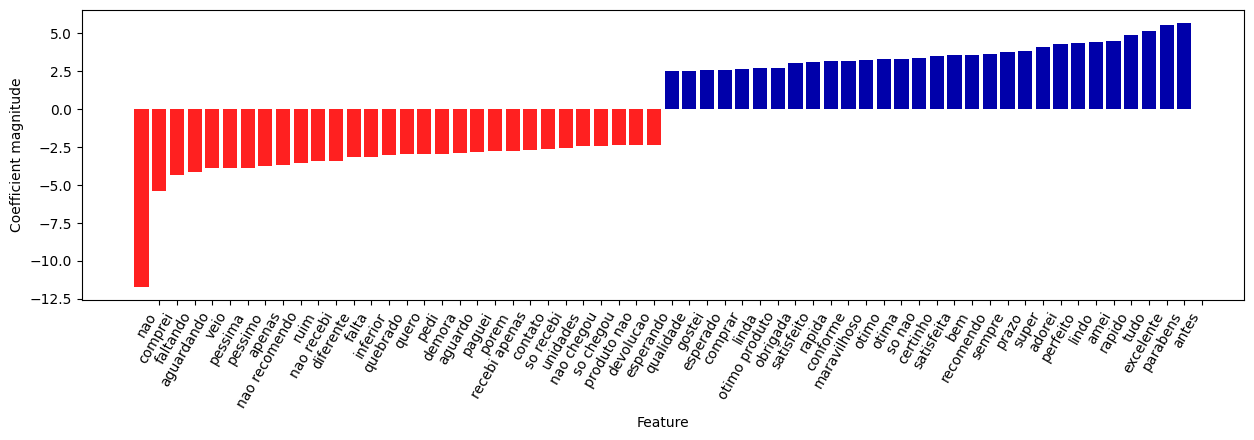

In [83]:
feature_names = vetorizador_tfidf.get_feature_names_out()

visualize_coefficients(
    classificador.coef_,
    feature_names,
    n_top_features=30
)

**Análise**: O modelo aprendeu muito bem e teve uma acurácia de 90% quando aplicado na base de teste. Podemos ver no gráfico agora quais palavras mais impactam positivamente ou negativamente na variável alvo que é a satisfação do cliente com base no comentário fornecido.

### PARTE IV Prática com dados categóricos

Questão 11: Imprima uma lista com as variáveis categóricas do dataset e a cardinalidade de cada uma, em ordem decrescente, ou seja, da maior cardinalidade para a menor. Vetorize as de baixa cardinalidade (< 50 categorias) utlizando a técnica One-Hot.

In [88]:
cols_categoricas = df_clean.select_dtypes(include='object').columns
print(f"Colunas categóricas:\n{cols_categoricas}")

Colunas categóricas:
Index(['customer_unique_id', 'customer_city', 'customer_state', 'order_status',
       'order_approved_at', 'shipping_limit_date',
       'order_delivered_carrier_date', 'order_estimated_delivery_date',
       'product_id', 'seller_id', 'product_category_name',
       'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp',
       'categorizacao_qnt_photos'],
      dtype='object')


In [90]:
cardinalidade = {}

for col in cols_categoricas:
  cardinalidade[col] = df_clean[col].nunique()

df_cardinalidade = pd.DataFrame.from_dict(cardinalidade, orient='index', columns=['cardinalidade'])

df_cardinalidade.sort_values(by='cardinalidade', ascending=False)

,cardinalidade
review_answer_timestamp,93926
customer_unique_id,91251
shipping_limit_date,89338
order_approved_at,86366
order_delivered_carrier_date,78255
review_comment_message,33881
product_id,31447
review_comment_title,4336
customer_city,4028
seller_id,2909


In [91]:
cols_baixa_card = df_cardinalidade[df_cardinalidade['cardinalidade'] < 50].index.tolist()

print(cols_baixa_card)

['customer_state', 'order_status', 'categorizacao_qnt_photos']


In [93]:
df_one_hot_encoding = pd.get_dummies(df_clean[cols_baixa_card], drop_first=True)
df_one_hot_encoding.head()

,customer_state_AL,customer_state_AM,customer_state_AP,customer_state_BA,customer_state_CE,customer_state_DF,customer_state_ES,customer_state_GO,customer_state_MA,customer_state_MG,...,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO,order_status_delivered,categorizacao_qnt_photos_Mínimo,categorizacao_qnt_photos_Razoável,categorizacao_qnt_photos_Ótimo
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,True,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,True,True,False,False


Questão 12: Aplique Feature Hashing nas features de localização do cliente customer_zip_code_prefix e customer_city. O CEP (ZipCode) é uma feature de alta cardinalidade que tipicamente já contém ruído e erros de preenchimento, ensejando a aplicação de hashing. Empregue como nova dimensionalidade aproximadamente 2 × log₂(N), onde N é a cardinalidade original.

In [95]:
cols_fh = ['customer_zip_code_prefix', 'customer_city']

card_total = df_clean[['customer_zip_code_prefix', 'customer_city']].nunique().sum()

print(card_total)

18706


In [96]:
dim_hash = 2 * np.log2(card_total)

print(dim_hash)

28.38242694444257


In [102]:
df_fh = df.copy()

df_fh['customer_zip_code_prefix'] = df_fh['customer_zip_code_prefix'].astype(str)
df_fh['customer_city'] = df_fh['customer_city'].astype(str)

hasher = FeatureHasher(n_features=int(dim_hash), input_type='string')

X_hash_input = df_fh[['customer_zip_code_prefix', 'customer_city']].values.tolist()

X_hash = hasher.transform(X_hash_input)

In [105]:
df_fh_hash = pd.DataFrame(
    X_hash.toarray(),
    columns=[f'hash_{i}' for i in range(int(dim_hash))]
)

df_fh_hash.head()

,hash_0,hash_1,hash_2,hash_3,hash_4,hash_5,hash_6,hash_7,hash_8,hash_9,...,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [112]:
df_final =pd.concat([df_clean, df_one_hot_encoding, df_fh_hash], axis=1)

df_final.head()

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,...,hash_18,hash_19,hash_20,hash_21,hash_22,hash_23,hash_24,hash_25,hash_26,hash_27
0,861eff4711a542e4b93843c6dd7febb0,14409.0,franca,SP,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-22 15:22:12,2017-05-23 10:47:57,2017-06-05 00:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,290c77bc529b7ac935b93aa66c333dc3,9790.0,sao bernardo do campo,SP,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-18 20:58:32,2018-01-15 17:14:59,2018-02-06 00:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,060e732b5b29e8181a18229c7b0b2b5e,1151.0,sao paulo,SP,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-05 16:19:10,2018-06-11 14:31:00,2018-06-13 00:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,259dac757896d24d7702b9acbbff3f3c,8775.0,mogi das cruzes,SP,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 16:31:16,2018-03-27 23:22:42,2018-04-10 00:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,345ecd01c38d18a9036ed96c73b8d066,13056.0,campinas,SP,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-31 10:10:09,2018-07-30 15:16:00,2018-08-15 00:00:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Questão 13: Aplique Bin Counting nas features identificadoras agregáveis: product_id, customer_unique_id e seller_id.

In [108]:
cols_bin_counting = ['product_id', 'customer_unique_id', 'seller_id']

df_bin_counting = df_clean.copy()

for col in cols_bin_counting:
  df_bin_counting[col + '_count'] = df_bin_counting[col].map(df_bin_counting[col].value_counts())

df_bin_counting.head()

,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,...,freight_value_log,dias_entrega_log,review_score_bin,categorizacao_qnt_photos,price_log_scaled,freight_value_log_scaled,dias_entrega_log_scaled,product_id_count,customer_unique_id_count,seller_id_count
0,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-22 15:22:12,2017-05-23 10:47:57,2017-06-05 00:00:00,...,3.130263,2.282382,1.0,Mínimo,0.555000,0.455103,-0.219829,59,1,1355
1,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-18 20:58:32,2018-01-15 17:14:59,2018-02-06 00:00:00,...,3.860309,2.873565,1.0,Razoável,1.476672,1.842345,0.764489,46,1,46
2,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-05 16:19:10,2018-06-11 14:31:00,2018-06-13 00:00:00,...,2.933325,3.299534,1.0,Mínimo,0.678967,0.080878,1.473727,10,1,1355
3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 16:31:16,2018-03-27 23:22:42,2018-04-10 00:00:00,...,3.192942,2.772589,1.0,Mínimo,0.754750,0.574207,0.596364,20,1,1355
4,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-31 10:10:09,2018-07-30 15:16:00,2018-08-15 00:00:00,...,3.146305,2.525729,1.0,Mínimo,1.225200,0.485586,0.185342,4,1,1947


In [113]:
df_final = pd.concat([df_final, df_bin_counting], axis=1)

df_final = df_final.drop(cols_bin_counting, axis=1)

df_final.head()

,customer_zip_code_prefix,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,order_delivered_customer_date,...,freight_value_log,dias_entrega_log,review_score_bin,categorizacao_qnt_photos,price_log_scaled,freight_value_log_scaled,dias_entrega_log_scaled,product_id_count,customer_unique_id_count,seller_id_count
0,14409.0,franca,SP,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-22 15:22:12,2017-05-23 10:47:57,2017-06-05 00:00:00,2017-05-25 10:35:35,...,3.130263,2.282382,1.0,Mínimo,0.555000,0.455103,-0.219829,59.0,1.0,1355.0
1,9790.0,sao bernardo do campo,SP,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-18 20:58:32,2018-01-15 17:14:59,2018-02-06 00:00:00,2018-01-29 12:41:19,...,3.860309,2.873565,1.0,Razoável,1.476672,1.842345,0.764489,46.0,1.0,46.0
2,1151.0,sao paulo,SP,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-05 16:19:10,2018-06-11 14:31:00,2018-06-13 00:00:00,2018-06-14 17:58:51,...,2.933325,3.299534,1.0,Mínimo,0.678967,0.080878,1.473727,10.0,1.0,1355.0
3,8775.0,mogi das cruzes,SP,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 16:31:16,2018-03-27 23:22:42,2018-04-10 00:00:00,2018-03-28 16:04:25,...,3.192942,2.772589,1.0,Mínimo,0.754750,0.574207,0.596364,20.0,1.0,1355.0
4,13056.0,campinas,SP,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-31 10:10:09,2018-07-30 15:16:00,2018-08-15 00:00:00,2018-08-09 20:55:48,...,3.146305,2.525729,1.0,Mínimo,1.225200,0.485586,0.185342,4.0,1.0,1947.0


In [114]:
df_final = df_final.drop(cols_fh, axis=1)

df_final.head()

,customer_state,order_status,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,order_delivered_customer_date,order_item_id,price,...,freight_value_log,dias_entrega_log,review_score_bin,categorizacao_qnt_photos,price_log_scaled,freight_value_log_scaled,dias_entrega_log_scaled,product_id_count,customer_unique_id_count,seller_id_count
0,SP,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-22 15:22:12,2017-05-23 10:47:57,2017-06-05 00:00:00,2017-05-25 10:35:35,1.0,124.99,...,3.130263,2.282382,1.0,Mínimo,0.555000,0.455103,-0.219829,59.0,1.0,1355.0
1,SP,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-18 20:58:32,2018-01-15 17:14:59,2018-02-06 00:00:00,2018-01-29 12:41:19,1.0,289.00,...,3.860309,2.873565,1.0,Razoável,1.476672,1.842345,0.764489,46.0,1.0,46.0
2,SP,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-05 16:19:10,2018-06-11 14:31:00,2018-06-13 00:00:00,2018-06-14 17:58:51,1.0,139.94,...,2.933325,3.299534,1.0,Mínimo,0.678967,0.080878,1.473727,10.0,1.0,1355.0
3,SP,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 16:31:16,2018-03-27 23:22:42,2018-04-10 00:00:00,2018-03-28 16:04:25,1.0,149.94,...,3.192942,2.772589,1.0,Mínimo,0.754750,0.574207,0.596364,20.0,1.0,1355.0
4,SP,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-31 10:10:09,2018-07-30 15:16:00,2018-08-15 00:00:00,2018-08-09 20:55:48,1.0,230.00,...,3.146305,2.525729,1.0,Mínimo,1.225200,0.485586,0.185342,4.0,1.0,1947.0


In [115]:
df_final = df_final.drop(cols_baixa_card, axis=1)

df_final.head()

,order_purchase_timestamp,order_approved_at,shipping_limit_date,order_delivered_carrier_date,order_estimated_delivery_date,order_delivered_customer_date,order_item_id,price,freight_value,product_category_name,...,price_log,freight_value_log,dias_entrega_log,review_score_bin,price_log_scaled,freight_value_log_scaled,dias_entrega_log_scaled,product_id_count,customer_unique_id_count,seller_id_count
0,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-22 15:22:12,2017-05-23 10:47:57,2017-06-05 00:00:00,2017-05-25 10:35:35,1.0,124.99,21.88,moveis_escritorio,...,4.836203,3.130263,2.282382,1.0,0.555000,0.455103,-0.219829,59.0,1.0,1355.0
1,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-18 20:58:32,2018-01-15 17:14:59,2018-02-06 00:00:00,2018-01-29 12:41:19,1.0,289.00,46.48,utilidades_domesticas,...,5.669881,3.860309,2.873565,1.0,1.476672,1.842345,0.764489,46.0,1.0,46.0
2,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-05 16:19:10,2018-06-11 14:31:00,2018-06-13 00:00:00,2018-06-14 17:58:51,1.0,139.94,17.79,moveis_escritorio,...,4.948334,2.933325,3.299534,1.0,0.678967,0.080878,1.473727,10.0,1.0,1355.0
3,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 16:31:16,2018-03-27 23:22:42,2018-04-10 00:00:00,2018-03-28 16:04:25,1.0,149.94,23.36,moveis_escritorio,...,5.016882,3.192942,2.772589,1.0,0.754750,0.574207,0.596364,20.0,1.0,1355.0
4,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-31 10:10:09,2018-07-30 15:16:00,2018-08-15 00:00:00,2018-08-09 20:55:48,1.0,230.00,22.25,casa_conforto,...,5.442418,3.146305,2.525729,1.0,1.225200,0.485586,0.185342,4.0,1.0,1947.0


Questão 14: Aplique PCA no dataset resultante das transformações efetuadas até o momento, removendo antes as features textuais, as features de datas, e as features originais das transformações que você realizou. Remova o review_score binarizado, que deverá ser usado como variável-alvo do PCA. Não esqueça de remover também o review_score original para não haver vazamento de informação para o modelo. Execute o PCA para k componentes tal que k explique 95% da variância dos dados.

In [117]:
df_clean.columns

Index(['customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'shipping_limit_date',
       'order_delivered_carrier_date', 'order_estimated_delivery_date',
       'order_delivered_customer_date', 'order_item_id', 'product_id',
       'seller_id', 'price', 'freight_value', 'product_category_name',
       'product_photos_qty', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'dias_entrega', 'price_log',
       'freight_value_log', 'dias_entrega_log', 'review_score_bin',
       'categorizacao_qnt_photos', 'price_log_scaled',
       'freight_value_log_scaled', 'dias_entrega_log_scaled'],
      dtype='object')

In [118]:
remover_cols = [
    'review_score',
    'review_score_bin',
    'review_comment_message',
    'order_purchase_timestamp',
    'order_aproved_at',
    'shipping_limit_date',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'review_creation_date',
    'review_answer_timestamp'
]

In [119]:
X = df_final.drop(remover_cols, axis=1, errors='ignore')
y = df_final['review_score_bin']

In [120]:
X = X.select_dtypes(include=['int64', 'float64'])
X

,order_item_id,price,freight_value,product_photos_qty,dias_entrega,price_log,freight_value_log,dias_entrega_log,price_log_scaled,freight_value_log_scaled,...,dias_entrega,price_log,freight_value_log,dias_entrega_log,price_log_scaled,freight_value_log_scaled,dias_entrega_log_scaled,product_id_count,customer_unique_id_count,seller_id_count
0,1.0,124.99,21.88,1.0,8.8,4.836203,3.130263,2.282382,0.555000,0.455103,...,8.8,4.836203,3.130263,2.282382,0.555000,0.455103,-0.219829,59.0,1.0,1355.0
1,1.0,289.00,46.48,3.0,16.7,5.669881,3.860309,2.873565,1.476672,1.842345,...,16.7,5.669881,3.860309,2.873565,1.476672,1.842345,0.764489,46.0,1.0,46.0
2,1.0,139.94,17.79,1.0,26.1,4.948334,2.933325,3.299534,0.678967,0.080878,...,26.1,4.948334,2.933325,3.299534,0.678967,0.080878,1.473727,10.0,1.0,1355.0
3,1.0,149.94,23.36,1.0,15.0,5.016882,3.192942,2.772589,0.754750,0.574207,...,15.0,5.016882,3.192942,2.772589,0.754750,0.574207,0.596364,20.0,1.0,1355.0
4,1.0,230.00,22.25,1.0,11.5,5.442418,3.146305,2.525729,1.225200,0.485586,...,11.5,5.442418,3.146305,2.525729,1.225200,0.485586,0.185342,4.0,1.0,1947.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112846,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112901,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
# Removendo nulos

X = X.dropna()
y = y.loc[X.index]

In [124]:
X

,order_item_id,price,freight_value,product_photos_qty,dias_entrega,price_log,freight_value_log,dias_entrega_log,price_log_scaled,freight_value_log_scaled,...,dias_entrega,price_log,freight_value_log,dias_entrega_log,price_log_scaled,freight_value_log_scaled,dias_entrega_log_scaled,product_id_count,customer_unique_id_count,seller_id_count
0,1.0,124.99,21.88,1.0,8.8,4.836203,3.130263,2.282382,0.555000,0.455103,...,8.8,4.836203,3.130263,2.282382,0.555000,0.455103,-0.219829,59.0,1.0,1355.0
1,1.0,289.00,46.48,3.0,16.7,5.669881,3.860309,2.873565,1.476672,1.842345,...,16.7,5.669881,3.860309,2.873565,1.476672,1.842345,0.764489,46.0,1.0,46.0
2,1.0,139.94,17.79,1.0,26.1,4.948334,2.933325,3.299534,0.678967,0.080878,...,26.1,4.948334,2.933325,3.299534,0.678967,0.080878,1.473727,10.0,1.0,1355.0
3,1.0,149.94,23.36,1.0,15.0,5.016882,3.192942,2.772589,0.754750,0.574207,...,15.0,5.016882,3.192942,2.772589,0.754750,0.574207,0.596364,20.0,1.0,1355.0
4,1.0,230.00,22.25,1.0,11.5,5.442418,3.146305,2.525729,1.225200,0.485586,...,11.5,5.442418,3.146305,2.525729,1.225200,0.485586,0.185342,4.0,1.0,1947.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113002,1.0,74.90,13.88,2.0,6.2,4.329417,2.700018,1.974081,-0.005276,-0.362454,...,6.2,4.329417,2.700018,1.974081,-0.005276,-0.362454,-0.733151,5.0,1.0,91.0
113003,1.0,114.90,14.16,1.0,7.4,4.752728,2.718660,2.128232,0.462715,-0.327030,...,7.4,4.752728,2.718660,2.128232,0.462715,-0.327030,-0.476490,6.0,1.0,36.0
113004,1.0,37.00,19.04,1.0,31.0,3.637586,2.997730,3.465736,-0.770128,0.203262,...,31.0,3.637586,2.997730,3.465736,-0.770128,0.203262,1.750454,2.0,1.0,13.0
113005,1.0,689.00,22.07,1.0,13.0,6.536692,3.138533,2.639057,2.434973,0.470818,...,13.0,6.536692,3.138533,2.639057,2.434973,0.470818,0.374034,44.0,1.0,1139.0


In [126]:
pca = PCA(n_components=0.95)

X_pca = pca.fit_transform(X)

In [130]:
print(f"Base Final: {X.shape}")
print(f"Base após PCA: {X_pca.shape}")

print(f"Número de componentes: {pca.n_components_}")

Base Final: (108192, 53)
Base após PCA: (108192, 2)
Número de componentes: 2


Questão 15: Trace um gráfico de barras da variância explicada em função de k.

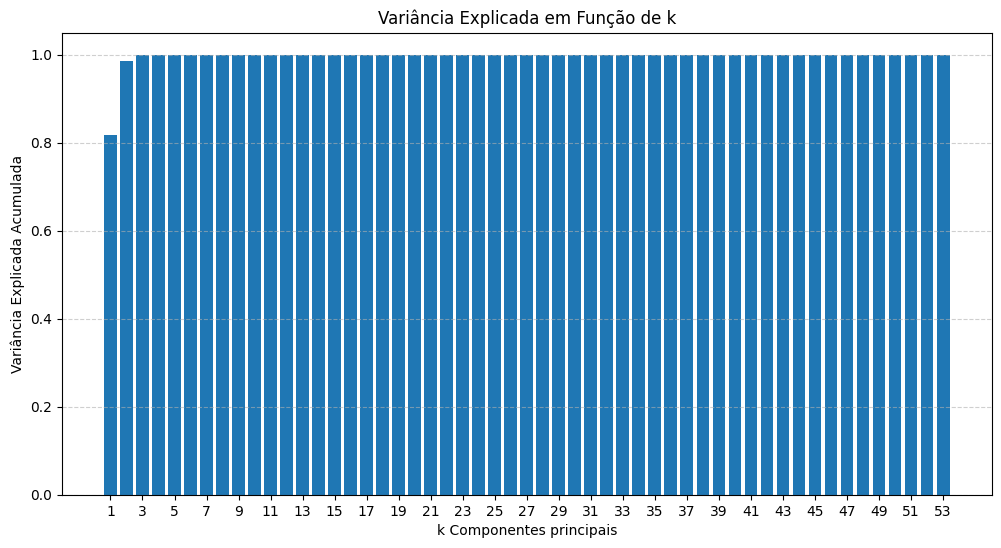

In [135]:
pca_n = PCA()
pca_n.fit(X)

k = len(pca_n.explained_variance_ratio_)

varianca_explicada = []

for i in range(1, k+1):
    soma = pca_n.explained_variance_ratio_[:i].sum()
    varianca_explicada.append(soma)

k_range = np.arange(1, k+1)

plt.figure(figsize=(12,6))

plt.bar(k_range, varianca_explicada)

plt.xlabel("k Componentes principais")
plt.ylabel("Variância Explicada Acumulada")
plt.title("Variância Explicada em Função de k")

plt.grid(True, axis='y', linestyle='--', alpha=0.6)

plt.xticks(k_range[::2])
plt.show()

Questão 16: Trace um gráfico de dispersão (scatter) bidimensional pontuando as instâncias dos dados no plano dos dois maiores componentes principais, colorindo as amostras de acordo com o review_score binarizado. Opcionalmente, trace também o gráfico de dispersão tridimensional, com os três maiores componentes principais.

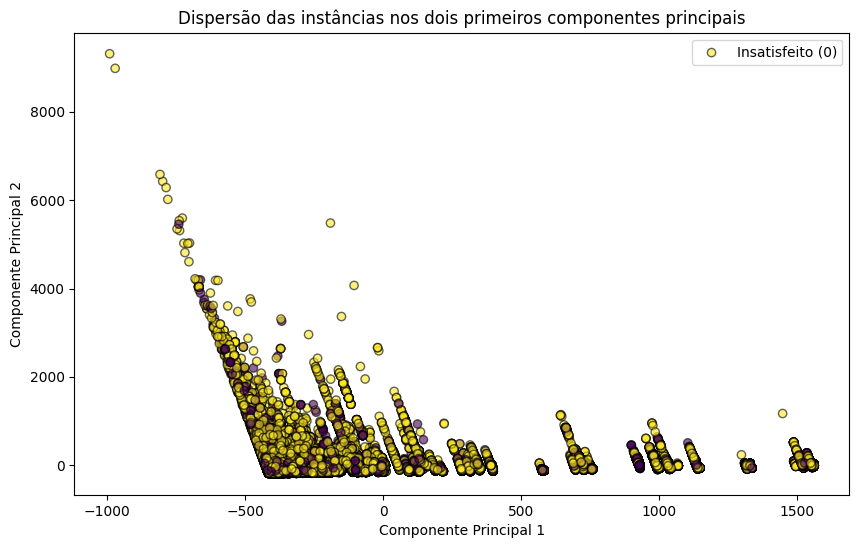

In [145]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y.iloc[:, 0],
    alpha=0.6,
    cmap='viridis',
    edgecolors='k',
    label='Insatisfeito (0)',
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Dispersão das instâncias nos dois primeiros componentes principais')
plt.legend()

plt.show()